In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pileup_C.pkl")
label_df = label_df[["ref", "pos"]].copy()
label_df.rename({"ref":"nmid"}, axis=1, inplace=True)
label_df["nmid"] = label_df["nmid"].str.split(".").str[0]
label_df["pos"] = label_df["pos"] - 1
label_df.reset_index(inplace=True)
label_df["index"] = label_df.index.astype(np.int32)
print(label_df)

             index          nmid   pos
0                0  NM_001100408     2
1                1  NM_001100408     3
2                2  NM_001100408     4
3                3  NM_001100408     5
4                4  NM_001100408     7
...            ...           ...   ...
29362466  29362466     NR_045019  1870
29362467  29362467     NR_045019  1880
29362468  29362468     NR_045019  1883
29362469  29362469     NR_045019  1890
29362470  29362470     NR_045019  1891

[29362471 rows x 3 columns]


In [196]:
m5c_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m5C-20240913-183902-47-469000-token_normalise_m5C_dwell_bq_npz_v2-ON0090_m5Cp95/pileup.npz"
with np.load(m5c_df, allow_pickle=True) as data:
    m5c_df = pd.DataFrame({key: data[key] for key in data.keys()})
m5c_df.rename(columns = {"label_id": "index"}, inplace = True)
m5c_df = m5c_df.merge(label_df, on="index", how="inner")
m5c_df["label_id"] = m5c_df["nmid"] + ":" + m5c_df["pos"].astype(str)
print(m5c_df)
m5c_df[["logsum_1_p_pos","count_all","count_dom","dom","label_id"]].to_pickle("/extdata4/baeklab/Hyeonseo/m6A/m5C/AIRNA-DW-v4-m5C-20240913-183902-47-469000-ON0090_p95.pkl")

             index     p_sum  logsum_1_p_pos  count_all  count_dom   dom  \
0                0  0.000812        0.000000          1          1  0.00   
1                1  0.104129        0.000000          4          4  0.00   
2                2  0.977536       -1.622519          5          5  0.20   
3                3  0.320513        0.000000          6          5  0.00   
4                4  0.044341        0.000000          6          6  0.00   
...            ...       ...             ...        ...        ...   ...   
29312742  29362466  0.220615        0.000000          5          4  0.00   
29312743  29362467  1.247681        0.000000          5          4  0.25   
29312744  29362468  0.987487       -1.875351          4          4  0.25   
29312745  29362469  0.000999        0.000000          3          3  0.00   
29312746  29362470  0.005462        0.000000          3          3  0.00   

          log_pm6a          nmid   pos        label_id  
0        -0.000000  NM_0011004

In [197]:
m5c_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m5C-20240913-183902-47-469000-token_normalise_m5C_dwell_bq_npz_v2-ON0090_m5Cp98/pileup.npz"
with np.load(m5c_df, allow_pickle=True) as data:
    m5c_df = pd.DataFrame({key: data[key] for key in data.keys()})
m5c_df.rename(columns = {"label_id": "index"}, inplace = True)
m5c_df = m5c_df.merge(label_df, on="index", how="inner")
m5c_df["label_id"] = m5c_df["nmid"] + ":" + m5c_df["pos"].astype(str)
print(m5c_df)
m5c_df[["logsum_1_p_pos","count_all","count_dom","dom","label_id"]].to_pickle("/extdata4/baeklab/Hyeonseo/m6A/m5C/AIRNA-DW-v4-m5C-20240913-183902-47-469000-ON0090_p98.pkl")

             index     p_sum  logsum_1_p_pos  count_all  count_dom   dom  \
0                0  0.000812        0.000000          1          1  0.00   
1                1  0.104129        0.000000          4          4  0.00   
2                2  0.977536        0.000000          5          5  0.20   
3                3  0.320513        0.000000          6          5  0.00   
4                4  0.044341        0.000000          6          6  0.00   
...            ...       ...             ...        ...        ...   ...   
29312742  29362466  0.220615        0.000000          5          4  0.00   
29312743  29362467  1.247681        0.000000          5          4  0.25   
29312744  29362468  0.987487       -1.875351          4          4  0.25   
29312745  29362469  0.000999        0.000000          3          3  0.00   
29312746  29362470  0.005462        0.000000          3          3  0.00   

          log_pm6a          nmid   pos        label_id  
0        -0.000000  NM_0011004

In [10]:
dai_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/Dai_UBS_293T_WT.txt", sep="\t")
huang_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/Huang_BS_293T_WT.txt", sep="\t")

print(dai_df)
print(huang_df)

     chrom   position strand       gene_type                   gene_name  \
0        .          .      +            rRNA               rRNA-RNA28SN1   
1        .          .      +            rRNA               rRNA-RNA28SN1   
2        .          .      +            tRNA            tRNA-Asp-GTC-1-1   
3        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
4        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
...    ...        ...    ...             ...                         ...   
2391     X  154477859      -  protein_coding      ENSG00000196976(LAGE3)   
2392     X  154485837      -  protein_coding      ENSG00000102178(UBL4A)   
2393     X  154488508      -  protein_coding    ENSG00000126903(SLC10A3)   
2394     X  155126223      +  Other features      ENSG00000185515(BRCC3)   
2395     Y   10200182      +      pseudogene  ENSG00000251705(RNA5-8SP6)   

     gene_pos  unconverted  converted     ratio  
0        3779         4305        186

In [14]:
atlas_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/m5Catlas_hg19.csv")

In [20]:
atlas_df = atlas_df[['seqnames', 'start', 'strand']]
print(atlas_df)

       seqnames      start strand
0          chr1      16735      -
1          chr1     135156      -
2          chr1     136341      -
3          chr1     662448      -
4          chr1     662839      -
...         ...        ...    ...
134644     chr2  242627224      +
134645     chr2  242627227      +
134646     chr7  128293553      +
134647     chr2  242627225      +
134648     chr8  145692679      +

[134649 rows x 3 columns]


In [21]:
import liftover

In [22]:
lo = liftover.get_lifter('hg19', 'hg38')

In [33]:
atlas_df["hg38"] = atlas_df.apply(lambda x: lo[x["seqnames"]][x["start"]], axis=1)

In [34]:
print(atlas_df)

       seqnames      start strand                    hg38
0          chr1      16735      -      [(chr1, 16735, +)]
1          chr1     135156      -     [(chr1, 135156, +)]
2          chr1     136341      -     [(chr1, 136341, +)]
3          chr1     662448      -     [(chr1, 727068, +)]
4          chr1     662839      -     [(chr1, 727459, +)]
...         ...        ...    ...                     ...
134644     chr2  242627224      +  [(chr2, 241687809, +)]
134645     chr2  242627227      +  [(chr2, 241687812, +)]
134646     chr7  128293553      +  [(chr7, 128653499, +)]
134647     chr2  242627225      +  [(chr2, 241687810, +)]
134648     chr8  145692679      +  [(chr8, 144467296, +)]

[134649 rows x 4 columns]


In [36]:
atlas_df["chr"] = atlas_df["hg38"].apply(lambda x: x[0][0])
atlas_df["pos"] = atlas_df["hg38"].apply(lambda x: x[0][1])

atlas_df = atlas_df[["chr", "pos", "strand"]]
print(atlas_df)

IndexError: list index out of range

In [40]:
print(atlas_df[atlas_df["hg38"].apply(lambda x: len(x) ==1)])

       seqnames      start strand                    hg38
0          chr1      16735      -      [(chr1, 16735, +)]
1          chr1     135156      -     [(chr1, 135156, +)]
2          chr1     136341      -     [(chr1, 136341, +)]
3          chr1     662448      -     [(chr1, 727068, +)]
4          chr1     662839      -     [(chr1, 727459, +)]
...         ...        ...    ...                     ...
134644     chr2  242627224      +  [(chr2, 241687809, +)]
134645     chr2  242627227      +  [(chr2, 241687812, +)]
134646     chr7  128293553      +  [(chr7, 128653499, +)]
134647     chr2  242627225      +  [(chr2, 241687810, +)]
134648     chr8  145692679      +  [(chr8, 144467296, +)]

[134644 rows x 4 columns]


In [42]:
atlas_df = atlas_df[atlas_df["hg38"].apply(lambda x: len(x) ==1)].copy()
atlas_df["chr"] = atlas_df["hg38"].apply(lambda x: x[0][0])
atlas_df["pos"] = atlas_df["hg38"].apply(lambda x: x[0][1])
atlas_df = atlas_df[["chr", "pos", "strand"]]
print(atlas_df)

KeyError: 'hg38'

In [134]:
ubs_df = dai_df.copy()
ubs_df["depth"] = ubs_df["unconverted"] + ubs_df["converted"]
ubs_df = ubs_df[(ubs_df["depth"] >= 20) & (ubs_df["ratio"] >= 0.1)].copy()
print(ubs_df)

     chrom   position strand       gene_type                 gene_name  \
0        .          .      +            rRNA             rRNA-RNA28SN1   
1        .          .      +            rRNA             rRNA-RNA28SN1   
3        .          .      +            tRNA          tRNA-Asp-GTC-2-1   
4        .          .      +            tRNA          tRNA-Asp-GTC-2-1   
5        .          .      +            tRNA          tRNA-Asp-GTC-2-1   
...    ...        ...    ...             ...                       ...   
2375     X  110317892      -  protein_coding  ENSG00000101935(AMMECR1)   
2380     X  123961780      +  protein_coding    ENSG00000101972(STAG2)   
2386     X  153700859      -  protein_coding   ENSG00000185825(BCAP31)   
2393     X  154488508      -  protein_coding  ENSG00000126903(SLC10A3)   
2394     X  155126223      +  Other features    ENSG00000185515(BRCC3)   

     gene_pos  unconverted  converted     ratio  depth  
0        3779         4305        186  0.958584   4491

In [135]:
ubs_df = ubs_df[["chrom", "position", "strand"]].copy()
ubs_df.rename(columns = {"chrom": "chr", "position": "pos"}, inplace = True)
ubs_df["chr"] = ubs_df["chr"].apply(lambda x: "chr" + x)
ubs_df = ubs_df[ubs_df["pos"]!="."].copy()
ubs_df["pos"] = ubs_df["pos"].astype(np.int64)
print(ubs_df)


       chr        pos strand
205   chr1     918816      -
206   chr1     941220      +
207   chr1     944475      +
212   chr1    1048884      +
214   chr1    1314332      -
...    ...        ...    ...
2375  chrX  110317892      -
2380  chrX  123961780      +
2386  chrX  153700859      -
2393  chrX  154488508      -
2394  chrX  155126223      +

[690 rows x 3 columns]


In [136]:
print(atlas_df)

         chr        pos strand  atlas
0       chr1      16735      -      1
1       chr1     135156      -      1
2       chr1     136341      -      1
3       chr1     727068      -      1
4       chr1     727459      -      1
...      ...        ...    ...    ...
134644  chr2  241687809      +      1
134645  chr2  241687812      +      1
134646  chr7  128653499      +      1
134647  chr2  241687810      +      1
134648  chr8  144467296      +      1

[134644 rows x 4 columns]


In [132]:
atlas_df["atlas"] = 1
ubs_df["ubs"] = 1
ubs_atlas_df = ubs_df.merge(atlas_df, on=["chr", "pos", "strand"], how="right")
ubs_atlas_df["ubs"].fillna(0, inplace=True)
print(ubs_atlas_df[ubs_atlas_df["ubs"]==1])

          chr        pos strand  ubs  atlas
6134    chr10   13499785      -  1.0      1
6430    chr10   34815098      -  1.0      1
6579    chr10   56358711      -  1.0      1
7008    chr10   89644848      -  1.0      1
7783    chr10  133362751      -  1.0      1
...       ...        ...    ...  ...    ...
134623  chr16    2175896      +  1.0      1
134636  chr15   90882311      +  1.0      1
134637  chr19   44871926      +  1.0      1
134638  chr17   82439944      +  1.0      1
134643   chr8  144467296      +  1.0      1

[282 rows x 5 columns]


In [155]:
m5c_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m5C/AIRNA-DW-v4-m5C-20240913-183902-47-469000-ON0090_p95.genomic.pkl")
m5c_df = m5c_df.reset_index(drop=True)
m5c_df = m5c_df.merge(ubs_df[["genome_id", "ubs"]], on="genome_id", how="left").fillna(0)
m5c_df["log_pm6a"] = -(2-m5c_df["dom"])*m5c_df["logsum_1_p_pos"]/m5c_df["count_all"] + (1-m5c_df["dom"])*np.log10(np.clip(1-m5c_df["dom"],1e-30,1))
print(m5c_df[m5c_df["ubs"]==1])
# print(m5c_df[m5c_df["atlas"]==1])

                 genome_id   gene_symbol  coding       dom  count_dom  \
7673     chr10:+:101003881         LZTS2    True  0.146465        198   
10923    chr10:+:101238571      LBX1-AS1   False  0.303571        112   
19819    chr10:+:102455624  C10orf95-AS1   False  0.076294        367   
61331    chr10:+:123155057          BUB3    True  0.084660       1382   
66515    chr10:+:127433340         DOCK1    True  0.153846         52   
...                    ...           ...     ...       ...        ...   
8460301    chrX:-:40074181          BCOR    True  0.246753        231   
8470988    chrX:-:48957281         OTUD5    True  0.148789        289   
8475624    chrX:-:49194237           SYP    True  0.310345         29   
8494233    chrX:-:71240386         ZMYM3    True  0.483412        211   
8509458    chrX:-:84061894       RPS6KA6    True  0.208333         24   

         logsum_1_p_pos  count_all  ubs  log_pm6a  
7673         -62.631119        205  1.0  0.507583  
10923       -157.90

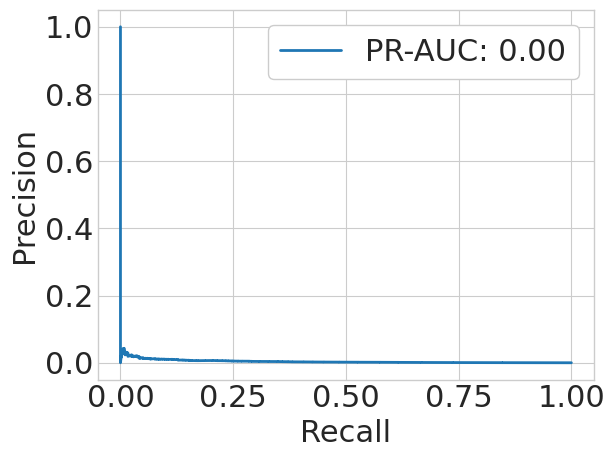

In [156]:
## P-R curve
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(m5c_df["ubs"], m5c_df["log_pm6a"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

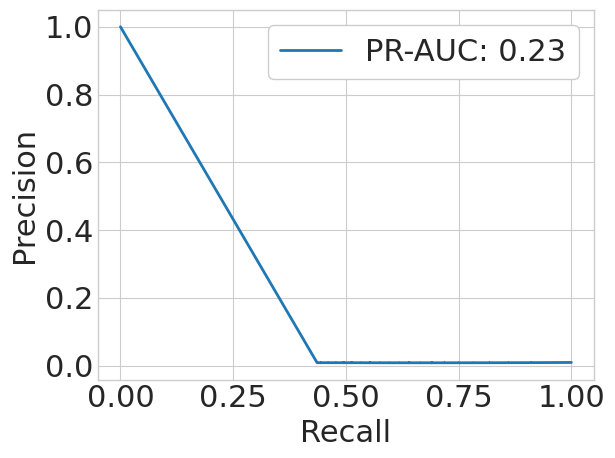

In [128]:
## P-R curve
from sklearn.metrics import precision_recall_curve, auc 
precision, recall, _ = precision_recall_curve(m5c_df["atlas"], m5c_df["logsum_1_p_pos"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [164]:
ubs_df = dai_df.copy()
ubs_df["depth"] = ubs_df["unconverted"] + ubs_df["converted"]
ubs_df["valid"] = (ubs_df["depth"] >= 20) & (ubs_df["ratio"] >= 0.1)
ubs_df = ubs_df[["chrom", "position", "strand","valid"]].copy()
ubs_df.rename(columns = {"chrom": "chr", "position": "pos"}, inplace = True)
ubs_df["chr"] = ubs_df["chr"].apply(lambda x: "chr" + x)
ubs_df = ubs_df[ubs_df["pos"]!="."].copy()
ubs_df["pos"] = ubs_df["pos"].astype(np.int64)
print(ubs_df)


       chr        pos strand  valid
205   chr1     918816      -   True
206   chr1     941220      +   True
207   chr1     944475      +   True
208   chr1     999131      -  False
209   chr1     999142      -  False
...    ...        ...    ...    ...
2391  chrX  154477859      -  False
2392  chrX  154485837      -  False
2393  chrX  154488508      -   True
2394  chrX  155126223      +   True
2395  chrY   10200182      +  False

[2191 rows x 4 columns]


In [176]:
ubs_atlas_df = ubs_df.merge(atlas_df, on=["chr", "pos", "strand"], how="outer").fillna(0)
ubs_atlas_df["valid"] = ubs_atlas_df["valid"].astype(int) * 2 - 1
ubs_atlas_df["genome_id"] = ubs_atlas_df["chr"] +":" + ubs_atlas_df["strand"]+ ":" + (ubs_atlas_df["pos"]-1).astype(str)
print(ubs_atlas_df)

         chr        pos strand  valid  atlas         genome_id
0       chr1     918816      -      1    0.0     chr1:-:918815
1       chr1     941220      +      1    1.0     chr1:+:941219
2       chr1     944475      +      1    0.0     chr1:+:944474
3       chr1     999131      -     -1    0.0     chr1:-:999130
4       chr1     999142      -     -1    0.0     chr1:-:999141
...      ...        ...    ...    ...    ...               ...
136307  chr7  128653520      +     -1    1.0  chr7:+:128653519
136308  chr2  241687809      +     -1    1.0  chr2:+:241687808
136309  chr2  241687812      +     -1    1.0  chr2:+:241687811
136310  chr7  128653499      +     -1    1.0  chr7:+:128653498
136311  chr2  241687810      +     -1    1.0  chr2:+:241687809

[136312 rows x 6 columns]


In [177]:
m5c_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m5C/AIRNA-DW-v4-m5C-20240913-183902-47-469000-ON0090_p95.genomic.pkl")
m5c_df = m5c_df.reset_index(drop=True)
m5c_df = m5c_df.merge(ubs_atlas_df[["genome_id", "valid"]], on="genome_id", how="left").fillna(0)
m5c_df["log_pm6a"] = -(2-m5c_df["dom"])*m5c_df["logsum_1_p_pos"]/m5c_df["count_all"] + (1-m5c_df["dom"])*np.log10(np.clip(1-m5c_df["dom"],1e-30,1))
print(m5c_df[m5c_df["valid"]==1])
# print(m5c_df[m5c_df["atlas"]==1])

                 genome_id   gene_symbol  coding       dom  count_dom  \
7673     chr10:+:101003881         LZTS2    True  0.146465        198   
10923    chr10:+:101238571      LBX1-AS1   False  0.303571        112   
19819    chr10:+:102455624  C10orf95-AS1   False  0.076294        367   
61331    chr10:+:123155057          BUB3    True  0.084660       1382   
66515    chr10:+:127433340         DOCK1    True  0.153846         52   
...                    ...           ...     ...       ...        ...   
8460301    chrX:-:40074181          BCOR    True  0.246753        231   
8470988    chrX:-:48957281         OTUD5    True  0.148789        289   
8475624    chrX:-:49194237           SYP    True  0.310345         29   
8494233    chrX:-:71240386         ZMYM3    True  0.483412        211   
8509458    chrX:-:84061894       RPS6KA6    True  0.208333         24   

         logsum_1_p_pos  count_all  valid  log_pm6a  
7673         -62.631119        205    1.0  0.507583  
10923       -15

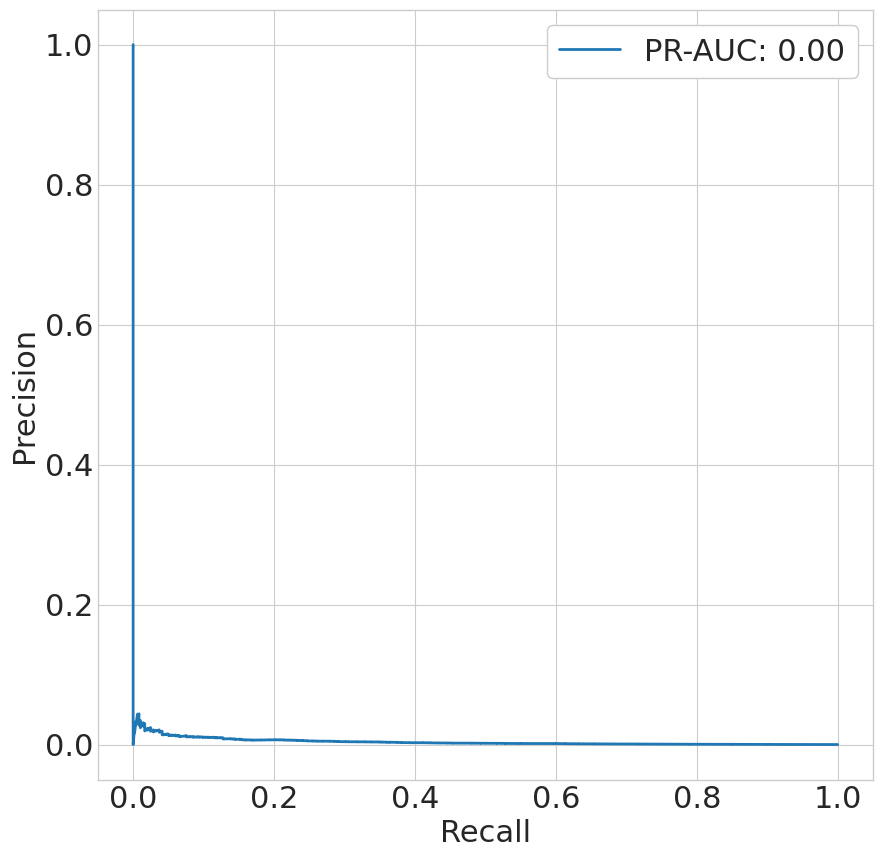

In [195]:
precision, recall, _ = precision_recall_curve(m5c_df[m5c_df["valid"]>=0]["valid"], m5c_df[m5c_df["valid"]>=0]["log_pm6a"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [181]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/dorado-080/ON0090_dorado_basecall.bed.m5C.genomic.pkl")
dorado_df = dorado_df.reset_index(drop=True).merge(ubs_atlas_df[["genome_id", "valid"]], on="genome_id", how="left").fillna(0)
dorado_df = dorado_df[dorado_df["coumt_dom"]>=20].copy()
print(dorado_df)


                genome_id gene_symbol       dom  count_dom  coding  valid
0         chr10:+:1000678      GTPBP4  0.000000          1    True    0.0
1         chr10:+:1000684      GTPBP4  0.004274        468    True    0.0
2         chr10:+:1000686      GTPBP4  0.006479        463    True    0.0
3         chr10:+:1000687      GTPBP4  0.000000          1    True    0.0
4         chr10:+:1000688      GTPBP4  0.010893        459    True    0.0
...                   ...         ...       ...        ...     ...    ...
22267274   chrX:-:9760807      GPR143  0.000000          4    True    0.0
22267275   chrX:-:9760809      GPR143  0.000000          5    True    0.0
22267276   chrX:-:9760810      GPR143  0.000000          4    True    0.0
22267277   chrX:-:9760814      GPR143  0.000000          5    True    0.0
22267278   chrX:-:9760815      GPR143  0.000000          3    True    0.0

[22267279 rows x 6 columns]


In [183]:
dorado_df = dorado_df[dorado_df["count_dom"]>=20].copy()
print(dorado_df)

                genome_id gene_symbol       dom  count_dom  coding  valid
1         chr10:+:1000684      GTPBP4  0.004274        468    True    0.0
2         chr10:+:1000686      GTPBP4  0.006479        463    True    0.0
4         chr10:+:1000688      GTPBP4  0.010893        459    True    0.0
5         chr10:+:1000689      GTPBP4  0.000000        496    True    0.0
6         chr10:+:1000696      GTPBP4  0.000000        439    True    0.0
...                   ...         ...       ...        ...     ...    ...
22266406   chrX:-:8732122       ANOS1  0.065789         76    True    0.0
22266407   chrX:-:8732125       ANOS1  0.000000         85    True    0.0
22266408   chrX:-:8732128       ANOS1  0.000000         68    True    0.0
22266409   chrX:-:8732131       ANOS1  0.015152         66    True    0.0
22266410   chrX:-:8732133       ANOS1  0.068182         44    True    0.0

[9641066 rows x 6 columns]


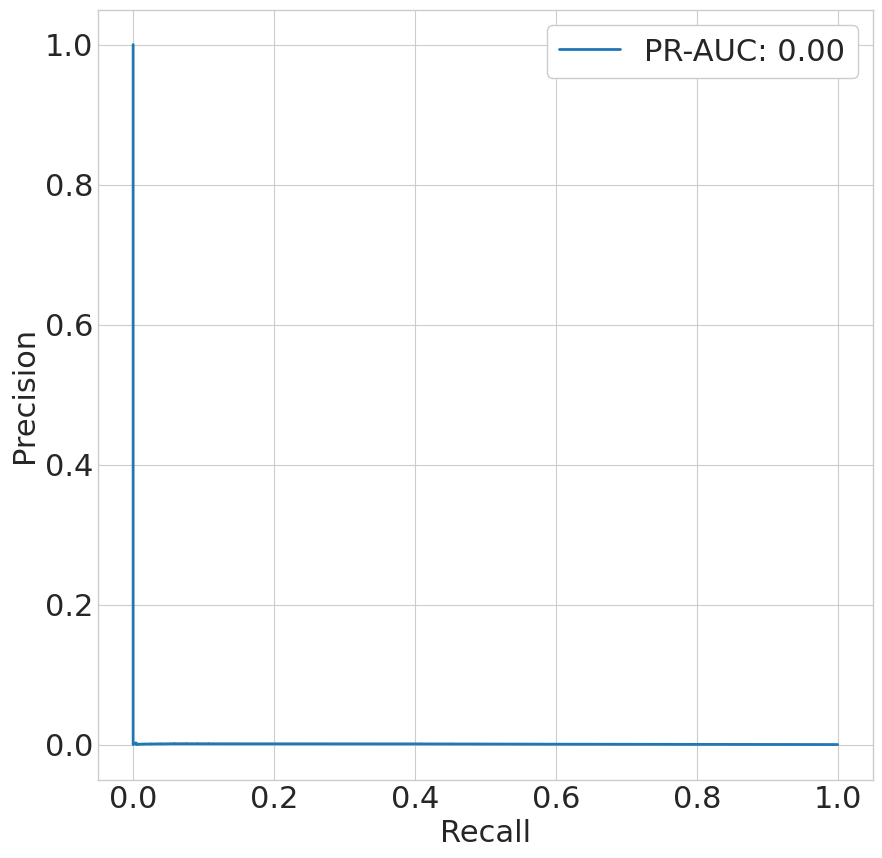

In [193]:
precision, recall, _ = precision_recall_curve(dorado_df[dorado_df["valid"]>=0]["valid"], dorado_df[dorado_df["valid"]>=0]["dom"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [185]:
print(dorado_df[dorado_df["valid"]==1])

                  genome_id   gene_symbol       dom  count_dom  coding  valid
17927     chr10:+:101003881         LZTS2  0.126984        189    True    1.0
23370     chr10:+:101238571      LBX1-AS1  0.402299         87   False    1.0
37769     chr10:+:102455624  C10orf95-AS1  0.046296        324   False    1.0
132892    chr10:+:123155057          BUB3  0.067221       1324    True    1.0
144078    chr10:+:127433340         DOCK1  0.018987        158    True    1.0
...                     ...           ...       ...        ...     ...    ...
22157564    chrX:-:48957281         OTUD5  0.029605        304    True    1.0
22166129    chrX:-:49194237           SYP  0.125000         24    True    1.0
22213570    chrX:-:66597463         EDA2R  0.100000         30    True    1.0
22220770    chrX:-:71240386         ZMYM3  0.097674        215    True    1.0
22259959    chrX:-:84061894       RPS6KA6  0.000000         53    True    1.0

[517 rows x 6 columns]


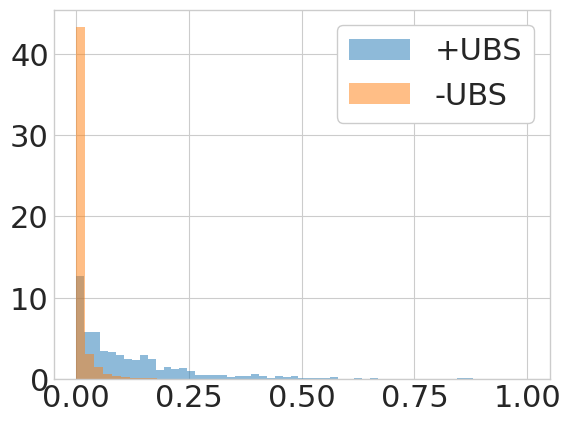

In [187]:
## Plot histogram
plt.hist(dorado_df[dorado_df["valid"]==1]["dom"], bins=50, alpha=0.5, label="+UBS",density=True)
plt.hist(dorado_df[dorado_df["valid"]==0]["dom"], bins=50, alpha=0.5, label="-UBS",density=True)
plt.legend()
plt.show()

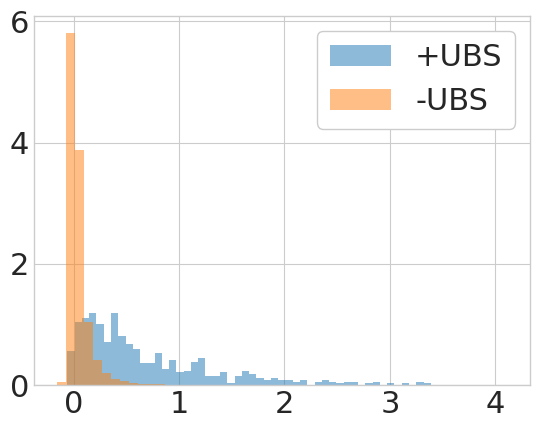

In [190]:
## Plot histogram
plt.hist(m5c_df[m5c_df["valid"]==1]["log_pm6a"], bins=50, alpha=0.5, label="+UBS",density=True)
plt.hist(m5c_df[m5c_df["valid"]==0]["log_pm6a"], bins=50, alpha=0.5, label="-UBS",density=True)
plt.legend()
plt.show()

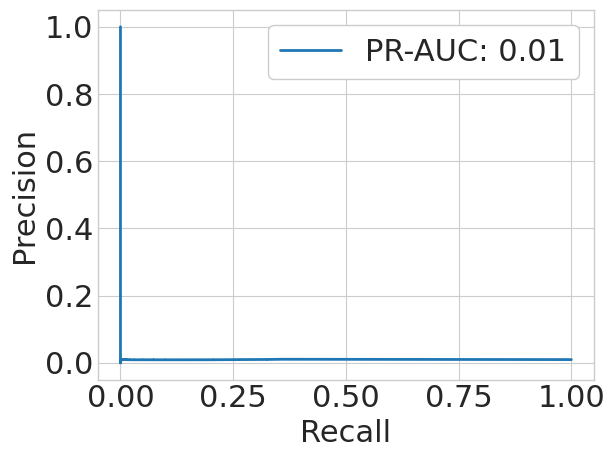

In [191]:
precision, recall, _ = precision_recall_curve(dorado_df["valid"].abs(), dorado_df["dom"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

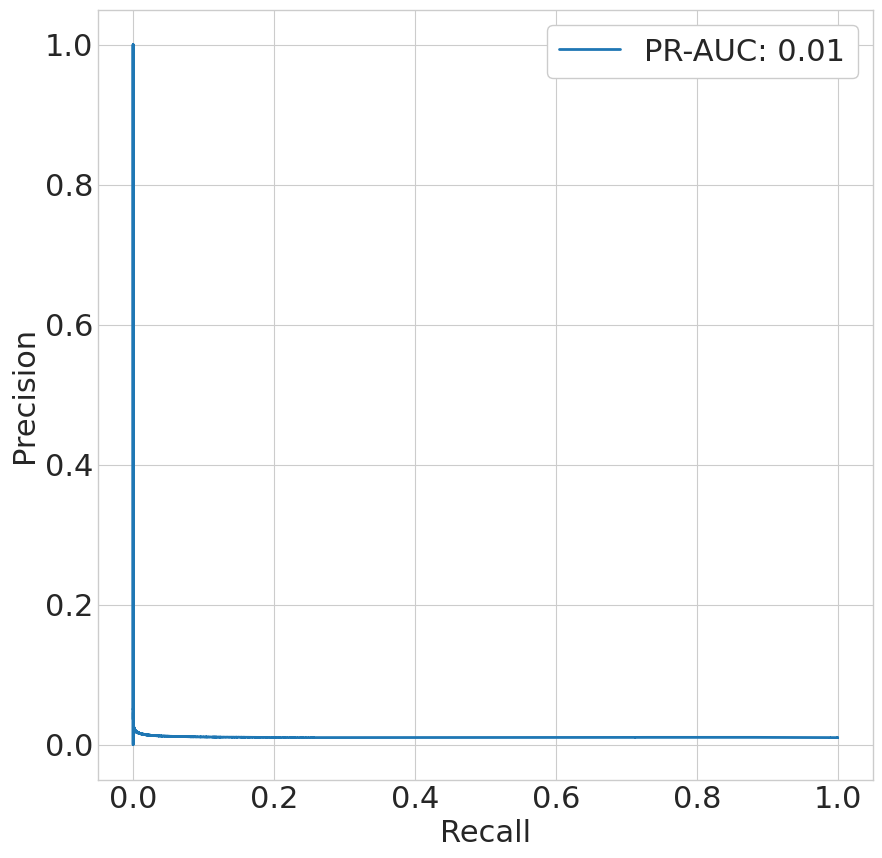

In [194]:
precision, recall, _ = precision_recall_curve(m5c_df["valid"].abs(), m5c_df["log_pm6a"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()